# Airbnb Analysis
## Teresa Ferrill  
#### December 7, 2025

This project uses Python to perform exploratory data analysis and visualization on New York City Airbnb listing data.     

Using the Airbnb dataset, I performed the following steps in Python:  
>1. Summarized the data then explored four questions    
>2. Created a histogram from the data    
>3. Created a boxplot from the data  
>4. Created a bivariate plot from the data    
>5. Created additional visualizations that support the questions answered  
>6. Summarized the results and explained how the visualizations support the conclusions  

The analysis uses the New York City Airbnb Open Data dataset, which contains 48,895 listings and 16 variables describing prices, room types, locations, availability, and review activity.  
Dataset file: [New York City Airbnb Open Data](https://www.kaggle.com/datasets/dgomonov/new-york-city-airbnb-open-data)  

>Context of dataset: This dataset describes Airbnb listing activity in New York City during 2019. It includes information about location, room type, price, availability, and review activity.    

Questions to visually explore the data:  
>Q1: What is the distribution of Airbnb listing prices?  Histogram   
>Q2: How do prices vary across different room types?  Boxplot  
>Q3: Is there a relationship between a listing’s price and its number of reviews?  Bivariate scatterplot
>Q4: What is the relationship between the price and the location of the Airbnb?  Boxplot 

-----------------------------------------------------------------------------------------------------------------
Basic dataset cleaning steps, part 1:  
> Load dataset  
> Identify number of rows and columns  
> Review columns and data

In [1]:
# Load dataset

# Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Set default style for all plots in the script to 
# a white background with grey grid lines
sns.set(style="whitegrid")  

# Load the dataset
df = pd.read_csv("../data/AB_NYC_2019.csv")

# Identify number of rows and columns
num_rows, num_cols = df.shape

# Print number of rows and columns
print(f"Number of rows: {num_rows}")
print(f"Number of columns: {num_cols}\n")

# Review columns and data
# Display sample records and dataset information
display(df.head())
df.info()

Number of rows: 48895
Number of columns: 16



,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

This initial block of code begins the exploration of the dataset.   
>The import statements include those libraries needed to support the plots required in steps 2 through 5

>The default style for all plots in all script blocks is standardized to a white background with grey grid lines, ensuring a consistent graph presentation style throughout all code  
  
>The dataset loaded without error or warning.
  
>Finally, general information about the dataset is computed and printed, providing helpful information for consideration in completing the data cleaning process  
>>1. Identify the number of rows and columns  
>>2. Print the number of rows and columns.  
>>3. Review the columns and sample records.

Side notes:  
This summary indicates that the dataset contains 48,895 Airbnb listings.  There are 16 columns capturing a mix of listing information, host details, geographic coordinates, and activity metrics.  The info() output shows that most columns are complete, with nearly all listings containing values for critical fields such as price, room_type, neighbourhood, and availability.  Four columns contain missing values. The name and host_name fields have relatively few missing values, while last_review and reviews_per_month each have 10,052 missing values.  This would suggest many listings have never been reviewed, indicating review-based features may need imputation or special handling if they are used during analysis.  

The dataset includes a combination of numeric (int64, float64) and categorical (object) data types.  Numeric fields such as price, minimum_nights, number_of_reviews, and availability_365 are ready for statistical analysis.  If used in modeling, I will have to perform encoding or grouping  on the categorical variables (including room_type, neighbourhood_group, and host_name).  Overall, I believe the structure  of the dataset is relatively clean and suitable for exploratory data analysis, descriptive statistics, and predictive modeling.  I will have to ensure that any missing values and categorical variables are handled appropriately.  

I will begin next steps by performing an exploratory data analysis (EDA) - checking for missing values, evaluating distributions of key numerical variables, identifying outliers, and reviewing correlations between features.  I will also review the dataset by handling missing data and identifying outliers that can skew analytical results.  Once these preparation steps are completed, I will work to form hypotheses and identify which variables may be most useful for predictive modeling or visualization.

-----------------------------------------------------------------------------------------------------------------
Basic dataset cleaning steps, part 2:  
> Select and retain columns to support analysis  
> Check for and remove duplicate listing identifiers 
> Remove zero and negative prices  

In [2]:
# Check the original dataset for duplicate listing IDs
duplicate_id_count = df["id"].duplicated().sum()
print("Duplicate listing IDs:", duplicate_id_count)

# Remove duplicate listing IDs only if they exist
df = df.drop_duplicates(subset="id")

# Keep only the columns needed for this analysis
columns_to_keep = [
    "neighbourhood_group",
    "neighbourhood",
    "latitude",
    "longitude",
    "room_type",
    "price",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365"
]

df = df[columns_to_keep].copy()

# Remove invalid price observations
df = df[df["price"].notna()]
df = df[df["price"] > 0]

print("Rows after cleaning:", df.shape)

Duplicate listing IDs: 0
Rows after cleaning: (48884, 11)


This block of code completes the exploration of the dataset.  
>Keep the features chosen to support analysis.  
>>Features selected include price, room type, neighbourhood, neighbourhood group, minimum nights, number of reviews, reviews per month, and availability 365.  

>Print out the resulting shape of the dataset after narrowing features  
>Check for duplicate listing identifiers before selecting the variables needed for analysis    
>Review the Price feature and remove zero and negative price values from dataset   
>Print the results of the basic cleaning efforts  

Side notes:  
I have narrowed the dataset to only the variables I believe are relevant for analysis.  This helps reduce noise and ensure further processing focuses on features most likely to influence price, demand, or listing performance.  
>These features were selected because they represent the core factors that influence Airbnb listing behavior, pricing, and demand.

Price is the primary variable examined in this analysis. Room type, neighbourhood, and neighbourhood group provide context about each listing’s accommodation type and location. Minimum nights represents booking restrictions, while number of reviews and reviews per month describe review activity. Availability_365 indicates the number of days a listing was recorded as available during the year.

Together, these variables provide a useful combination of pricing, location, booking, review, and availability information for exploratory analysis and visualization. They could also be evaluated as candidate features in future predictive modeling.

I then reviewed the price feature and removed rows with zero or negative prices.  
>These rows were removed as they represent invalid or non-meaningful listings that would distort averages, histograms, and predictive models.   

Overall, these transformations will improve data integrity and create a cleaner, more reliable dataset that is ready for exploratory analysis, visualization, and eventual modeling.  

-----------------------------------------------------------------------------------------------------------------
*2. Create a histogram*  
***Note*** - A histogram is appropriate because price is numerical. The chart groups nightly prices into intervals and shows how many listings fall within each price range.  

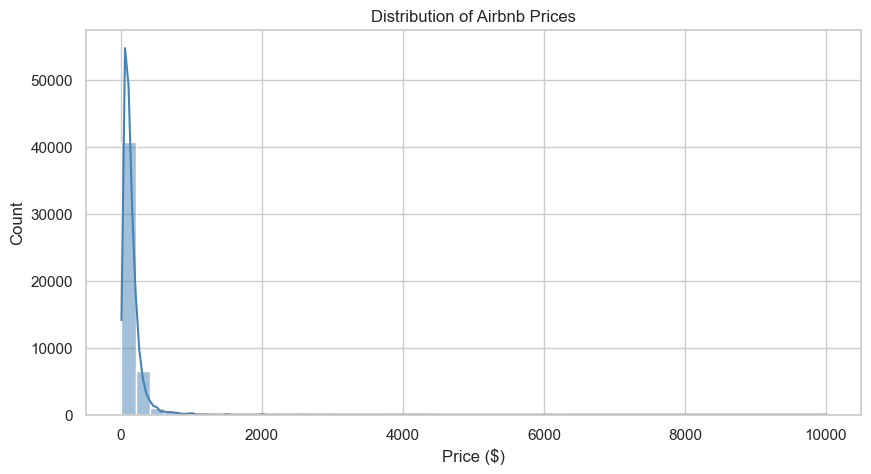

In [3]:
# Prepare histogram
plt.figure(figsize=(10,5))
sns.histplot(df["price"], bins=50, kde=True, color="steelblue")
plt.title("Distribution of Airbnb Prices")
plt.xlabel("Price ($)")
plt.ylabel("Count")
plt.show()

This block of code produces a histogram representing the distribution of Airbnb prices.  

>This code presents a visualization of the Airbnb listing prices in the dataset.  
>>The size of the plot is set, ensuring it is wide enough to display the price distribution    
>>The histogram is created using the price column, dividing the data into 50 bins to show how often listings fall within each price range  
>>The kde=True argument is used to overlay a kernel density estimation curve, providing a smooth line representing the overall distribution shape  
>>The color of the histogram is set to a steel blue shade for clarity  
>>The plot includes a descriptive title and labeled axes to make interpretation easier  

>Overall, this visualization helps reveal key pricing patterns—such as skewness, outliers, and the most common price ranges—allowing the price distribution to be assessed before performing deeper analysis or building predictive models.  

Side notes:  
>This histogram shows a highly right-skewed distribution.  Most listings are priced below $300, while a long tail extends toward properties costing several thousand dollars per night.   

>This pattern indicates that while the dataset contains a large volume of lower-priced listings, a relatively small number of expensive or higher-priced listings pull the upper range outward.  The KDE curve reinforces this shape by showing a steep peak at low prices and a gradual decline as the price increases.  
>The histogram shows the price distribution after checking duplicate listing identifiers and removing invalid price observations.   

Next Steps:  
For clearer analysis, I will create a trimmed dataset that keeps only listings priced at 500 dollars or less.  This will facilitate a study of typical pricing behavior, separate from higher-priced listings.

>I created a trimmed dataset that temporarily excludes listings priced above 500 dollars.  Listings priced above 500 dollars may be legitimate, but they are relatively uncommon and compress the scale of the visualization.
>>Remove the high-priced listings from the dataset  
>>Prepare revised histogram with updated dataset

Existing DataFrame shape: (48884, 11)
Number of listings priced above $500: 1044

Shape after excluding listings priced above $500:
Resulting shape: (47840, 11)


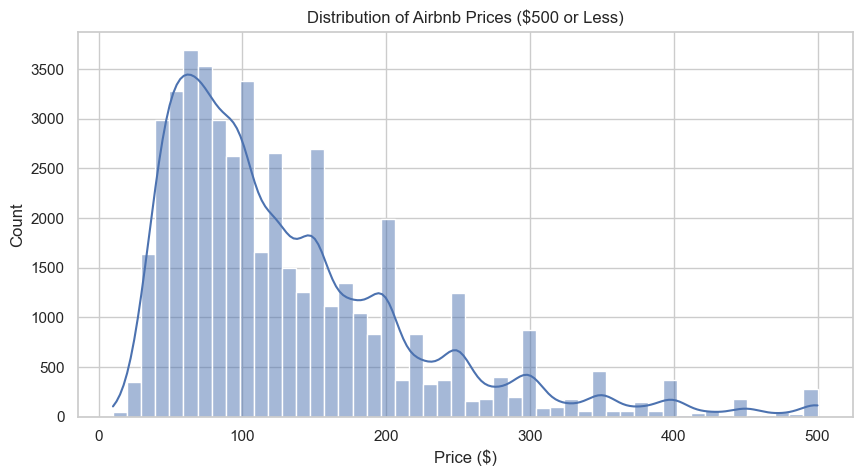

In [4]:
# Display the shape of the cleaned DataFrame
print("Existing DataFrame shape:", df.shape)

# Establish the upper-price threshold
threshold = 500

# Identify listings priced above the threshold
higher_priced_listings = df[df["price"] > threshold]

# Count the listings priced above the threshold
higher_priced_count = higher_priced_listings.shape[0]

print(f"Number of listings priced above ${threshold}: {higher_priced_count}")

# Create a trimmed DataFrame for the visualization
df_trim = df[df["price"] <= threshold].copy()

print("\nShape after excluding listings priced above $500:")
print("Resulting shape:", df_trim.shape)

# Produce the trimmed histogram
plt.figure(figsize=(10, 5))
sns.histplot(df_trim["price"], bins=50, kde=True)
plt.title("Distribution of Airbnb Prices ($500 or Less)")
plt.xlabel("Price ($)")
plt.ylabel("Count")
plt.show()

This block creates a separate dataset for visualization that temporarily excludes listings priced above 500 dollars.  Through the code:  
>I listed the count of rows before removing the higher-priced listings  
>Then I worked to count the listings priced above 500 dollars    
>>I established a threshold value of 500 dollars  
>>I created a filtered dataframe of those rows with a price above the threshold value
>>I then counted the number of rows in the filtered dataframe and printed the value

>Next, I established a trimmed dataframe, excluding higher-priced listings from the trimmed DataFrame    
>I then produced a histogram of the resulting, trimmed dataframe    

Side notes:  
This trimmed histogram provides a clearer view of the price distribution for listings priced at 500 dollars or less.  Most listings fall between 50 and 150, forming a strong right-skewed curve with a clear peak around the lower–mid price ranges.  

As price increases beyond 150, the number of listings steadily declines.  This shows that observations are concentrated in the lower and middle portions of the analyzed price range, while higher-priced listings occur less frequently.    

Choosing to focus on the price range up to 500 dollars helps make the distribution more meaningful for analysis.  Additionally, it provides clearer insights into typical pricing behavior.  This sets a more solid foundation for comparing prices across room types, neighborhoods, and other listing attributes.

This visualization temporarily excludes listings priced above 500 dollars to make the typical price distribution easier to examine.

-----------------------------------------------------------------------------------------------------------------
*3. Create a boxplot*

Unique room types:
['Private room' 'Entire home/apt' 'Shared room']

Room type counts:
room_type
Entire home/apt    24514
Private room       22176
Shared room         1150
Name: count, dtype: int64 



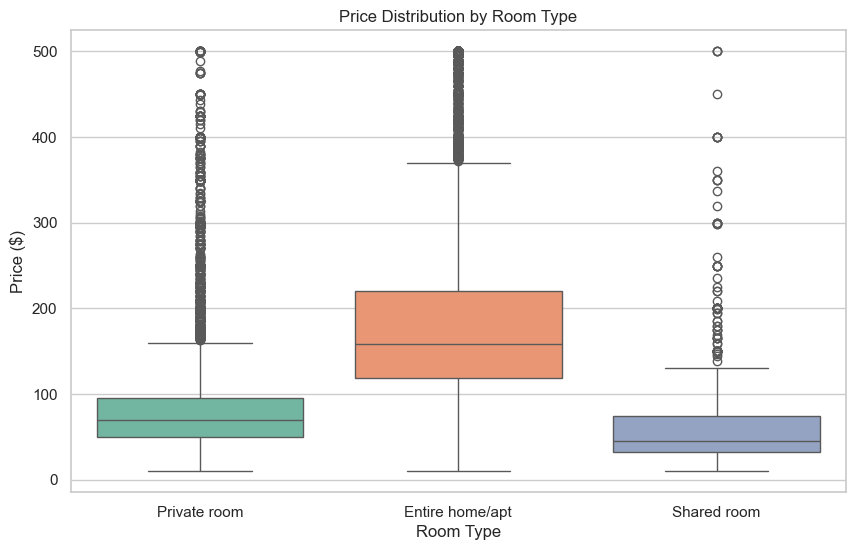

In [5]:
# Print unique room types
print("Unique room types:")
print(df_trim["room_type"].unique())

# Print counts of each room type
print("\nRoom type counts:")
print(df_trim["room_type"].value_counts(), "\n")

# Prepare boxplot
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df_trim,
    x="room_type",
    y="price",
    hue="room_type",     
    palette="Set2",
    legend=False         
)
plt.title("Price Distribution by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Price ($)")
plt.show()

This block of code produces a boxplot, visualizing the price distribution by room type.  
>The different room types are listed
>The number of listings in each room type is displayed.
>The boxplot is prepared, showing how Airbnb prices differ across the three room types  
>>Entire homes and apartments display the widest interquartile range, indicating greater variability in their listing prices.      

Side notes:  
>Both Private rooms and Shared rooms show lower and more tightly clustered price ranges, with Shared rooms having the lowest median price overall.  
>All three room-type categories contain listings above their typical price ranges. Entire homes and apartments have visibly higher median prices than private and shared rooms.

-----------------------------------------------------------------------------------------------------------------
*4. Create a bivariate plot*

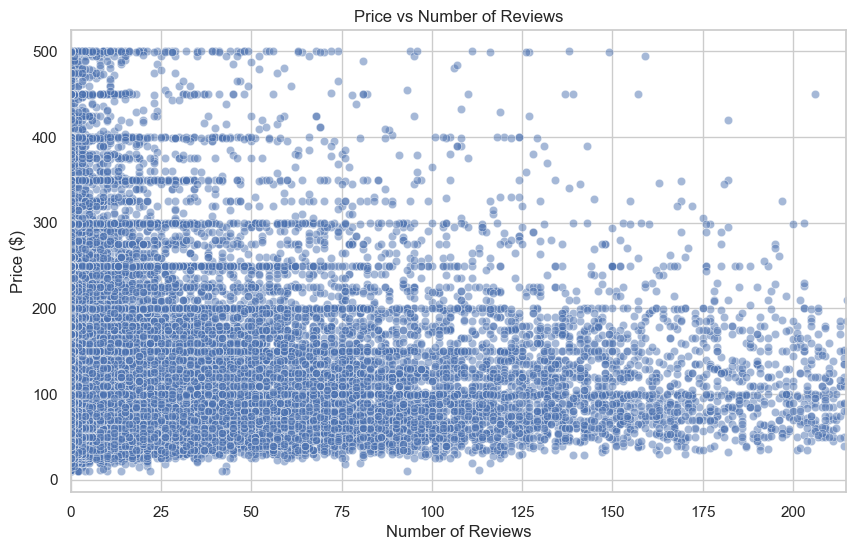

In [6]:
# Prepare bivariate plot
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_trim, x="number_of_reviews", y="price", alpha=0.5)
plt.title("Price vs Number of Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("Price ($)")
plt.xlim(0, df_trim["number_of_reviews"].quantile(0.99))
plt.show()

This block of code produces a bivariate plot visualizing price versus number of reviews.  
>A bivariate plot is used to visualize and analyze the relationship between two variables.  This helps to identify trends, patterns, and correlations (positive, negative, or none).  This information is crucial for making predictions and understanding how one variable might influence another.  In this case, the plot examines whether listing price and accumulated review count appear to be associated.

This code generates a scatter plot that visualizes the relationship between Airbnb listing price and the number of reviews.  
>The plot is sized to 10×6 inches for readability  
>Each point represents a listing  
>The alpha=0.5 parameter makes the points semi-transparent, so dense clusters are easier to see when many listings overlap   
>The title and axis labels help clarify what the plot represents  
>The plot restricts the x-axis to the 99th percentile of number of reviews  
>>This removes extreme outliers (those highly reviewed listings that could stretch the axis and compress the bulk of the data)  
>>***Note***: Focusing on the typical range of review counts ensures the plot presents a clearer picture of the main trend between price and review volume    


Side notes:  

This scatter plot shows the relationship between Airbnb listing price and the number of reviews. The distribution reveals that there is no strong linear relationship between the two variables.  
>This means that higher-priced listings do not necessarily have more or fewer reviews.  
>Most listings with numerous reviews fall within the lower price ranges, generally below 200 dollars.
>>Lower-priced listings tend to include more highly reviewed properties. However, review count does not directly measure occupancy, and the plot does not establish that lower prices cause more bookings. 

>Listings above 300 dollars appear less frequently and generally have fewer reviews, although the visualization does not establish the reason for this pattern.  
>Most observations are concentrated among listings below 200 dollars with low-to-moderate review counts

-----------------------------------------------------------------------------------------------------------------
*5. Create an additional visualization to address the remaining research question.*

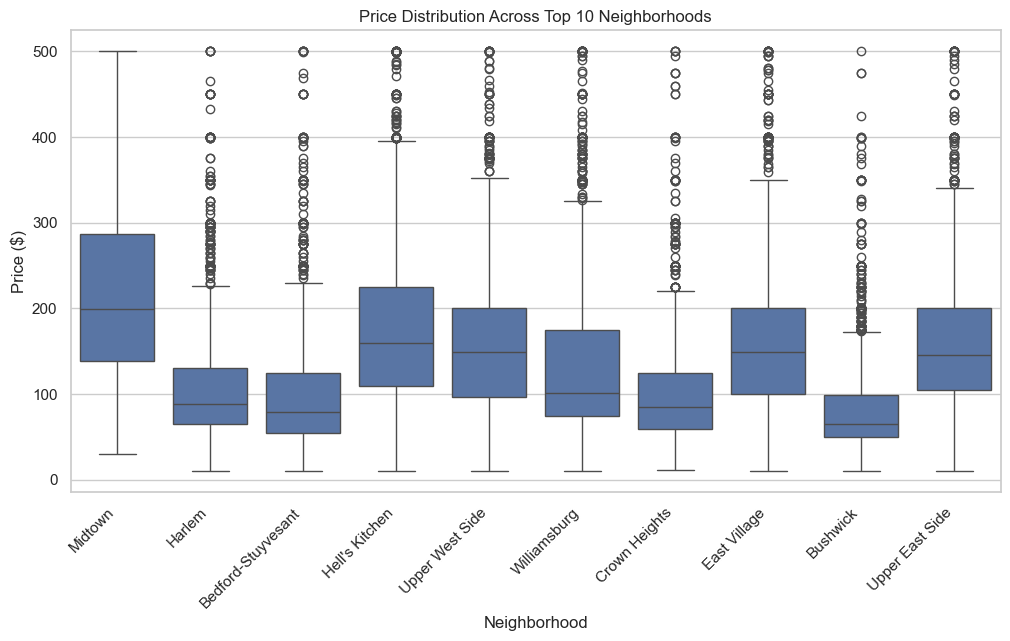

In [7]:
# Top 10 neighborhoods with most listings
top10 = df_trim["neighbourhood"].value_counts().head(10).index
df_top10 = df_trim[df_trim["neighbourhood"].isin(top10)]

# Additional boxplot graph
plt.figure(figsize=(12,6))
sns.boxplot(data=df_top10, x="neighbourhood", y="price")
plt.title("Price Distribution Across Top 10 Neighborhoods")
plt.xlabel("Neighborhood")
plt.ylabel("Price ($)")
plt.xticks(rotation=45, ha="right")
plt.show()

This block of code identifies the top 10 neighborhoods with the highest number of Airbnb listings then visualizes how prices vary across those neighborhoods.  
>Counts how many listings belong to each neighborhood, selecting the top 10 neighborhoods  
>The dataset is then filtered to include only listings from these neighborhoods  
>>This produces a new DataFrame containing the ten neighborhoods with the most Airbnb listings  

>Another boxplot is created to compare price distributions across these top neighborhoods
>>Each neighborhood appears on the x-axis
>>Its corresponding price distribution appears on the y-axis

>The boxplot highlights key statistical properties—median price, interquartile range (IQR), and outliers—for each neighborhood
>The axis labels and rotated tick labels improve readability, especially when neighborhood names are long

Side notes:  
The choice of the final boxplot proved significant in the analysis of price distribution.  
>Analyzing price distribution across the top 10 neighborhoods provides important context that the overall price histogram and room-type boxplots cannot capture.  
>>Neighborhood provides useful location context when comparing listing prices. Factors such as proximity to attractions, demand, and local housing conditions may contribute to the observed differences, but they are not evaluated directly in this analysis.  

>>By focusing on the neighborhoods with the most listings, the analysis shows where listings are concentrated and how their price distributions differ.    

The boxplot shows how listing-price distributions vary among the ten neighborhoods with the most listings.  
>Some neighborhoods show higher median prices and wider spreads.  This indicates greater price variation, which may reflect differences in room types or listing characteristics.

>Other neighborhoods display tighter price ranges, suggesting a more uniform market and fewer high-priced outliers.  
>The price variability may be associated with differences in room type, property characteristics, or other factors not directly evaluated in this analysis.    

Overall, the plot shows visible price differences among the selected neighborhoods. Additional statistical analysis would be needed to determine the strength and significance of this association.    

Prices vary across the selected neighborhoods, although the chart does not establish why those differences occur.

-----------------------------------------------------------------------------------------------------------------
*6. Summarize results and make a conclusion, explaining this conclusion and the chosen visualizations that support the conclusion.*

Summary of Results
Findings  
>Q1: What is the distribution of prices?  

>>The histogram shows that most Airbnb listings are priced between 50 and 200 dollars, with a long right-tail extending toward higher-priced listings.  
>>This indicates considerable variation in listing prices, although most observations fall within the lower and middle portions of the analyzed range.    

>Q2: How do prices vary by room type?  
 
>The boxplot reveals clear differences, indicating that listing prices differ visibly among room types:

>>Entire homes/apartments have the highest median price  
>>Private rooms have lower median prices  
>>Shared rooms are the lowest-cost option

>Q3: Is there a relationship between price and number of reviews?  

>The scatterplot shows a weak negative association between price and review count. Review count does not directly measure turnover or occupancy.
>>Lower-priced listings tend to have more reviews
>>Higher-priced listings tend to have fewer reviews  

>Q4: What is the relationship between the price and the location of the Airbnb?

>The boxplot reveals whether certain neighborhoods have higher prices, a greater price variability, or attract different types of listings:
>>The neighborhood boxplot shows visible price differences based on location.
>>Median prices and price ranges differ across the ten neighborhoods with the most listings.

Most listings fall within the lower and middle portions of the observed price range. However, affordability cannot be determined without comparing prices with visitor budgets or income.  

Conclusion
>Based on the visualizations:  
>>Most analyzed listings fall within the lower and middle portions of the observed price range. Affordability cannot be determined without considering visitor budgets or income.    
>>Room type is associated with price, with entire homes being the most expensive.  
>>Lower-priced listings tend to have more reviews, although review counts do not provide a direct measure of occupancy.  
>>Listing prices vary across the selected neighborhoods, although the analysis does not establish why those neighborhood differences occur.  

>These conclusions were supported by the histogram (price distribution), boxplot (price by room type), scatterplot (price vs reviews), and additional location-based visualizations.

Summary notes:  

The trimmed histogram provides a clearer view of the price distribution. Most listings are priced between $50 and $150, with a clear peak in the lower-to-middle price range and a right-skewed distribution.  

The first boxplot shows visible price differences among room types, with entire homes and apartments having higher median prices and a wider price distribution.    

This scatter plot illustrates the relationship between Airbnb listing price and the number of reviews, indicating that there is no clear linear pattern between the two variables.  

The final boxplot compares price distributions across the ten neighborhoods with the most listings. It shows differences in median prices, variability, and listings above the typical ranges. These results indicate that neighborhood should be considered in additional analysis, although this visualization does not establish the causes of the observed differences.    

Room type and neighborhood are associated with differences in listing prices. These findings support including both variables in future predictive analysis.  

Recommendations for further analysis:  
The analysis provides a clearer understanding of how price relates to room type, review activity, and neighborhood.  

Consider exploring:

Price vs. availability (Do more available listings tend to be cheaper or more expensive?)

Price vs. minimum nights (Higher minimum nights may correlate with specific pricing tiers.)

Review behavior across neighborhoods to understand guest demand trends.

Correlation matrix to quantify relationships between numerical variables.

-----------------------------------------------------------------------------------------------------------------
Follow on steps to support providing predictive insights for a potential Airbnb host include:

>Build a predictive pricing model that estimates a reasonable nightly rate
>>Based on features such as room type, neighborhood, availability, and review activity
>>Training regression models such as Linear Regression, Random Forest, or Gradient Boosting to predict what similar listings charge and provide a new host with an evidence-based price recommendation for their unit

>In addition to pricing, a host may want to understand how often their property might be booked.  Using variables like reviews per month and availability patterns to create models that estimate:
>>Expected demand to help anticipate occupancy trends
>>Identify which types of listings attract consistent guest traffic  

>I would also utilize clustering techniques to categorize listings into market segments such as budget rentals, mid-range entire homes, or higher-priced listings units.  This would help a prospective host understand where their property would fit within the local market and whether competing listings follow similar pricing and demand patterns.  

>Finally, I would recommend estimating potential revenue by combining predicted nightly price with expected occupancy rates.  This would transform the analysis into practical guidance, allowing hosts to forecast monthly or yearly income. Together, these predictive components make the project more valuable by offering clear, data-driven insights for anyone considering entering the Airbnb market.  